# Stage 7 - Execution on the noisy backend

In [1]:
import os, sys
ROOT = os.getcwd()
while not os.path.exists(os.path.join(ROOT, "src", "config.py")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        raise RuntimeError("Project root (folder containing src/) not found")
    ROOT = parent
os.chdir(ROOT)
sys.path.insert(0, ROOT)
os.makedirs("results/figures", exist_ok=True)

In [2]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt

from src import config as C
from src.device import NoisyDevice
from src.stages import execute_variants, VARIANT_DESCRIPTIONS, config_snapshot
from src.mitigation import assignment_matrix, fold_circuit, apply_readout_mitigation, zne_extrapolate
from src.metrics import hellinger_fidelity
from src.pipeline_io import load_stage_output, save_json, save_fig

BLUE, RED, GREEN, GREY, ORANGE, PURPLE = "#1f4e8c", "#c0392b", "#27ae60", "#7f8c8d", "#e67e22", "#8e44ad"
COLORS = {"ideal_noiseless": BLUE, "noisy_uncalibrated": RED, "uncalibrated_REM": "#f1948a",
          "6A_grid_REM": ORANGE, "6B_auto_REM": GREEN, "6B_auto_REM_ZNE": PURPLE}

s6 = load_stage_output("stage06_retuning.json")
for n in C.REGISTER_SIZES:
    print(f"{n}-qubit register -- commanded angles from Stage 6 (deg):")
    for k, v in s6[f"{n}_qubit"]["calibrated_parameters"].items():
        print(f"   {k:13s}: {np.round(np.rad2deg(v), 2)}")
print(f"\nShots per execution: {C.SHOTS_EXECUTION:,}   independent repetitions: {C.N_REPEATS}")

2-qubit register -- commanded angles from Stage 6 (deg):
   uncalibrated : [ 90.   195.35  40.42  -6.93]
   grid_6A      : [ 90.   234.    40.42  -1.43]
   auto_6B      : [ 70.4  224.51  50.85  -6.82]
3-qubit register -- commanded angles from Stage 6 (deg):
   uncalibrated : [ 89.99  55.04 131.01  40.42  -2.97]
   grid_6A      : [ 89.99 256.5  198.    52.42  -4.22]
   auto_6B      : [115.01  34.37 109.92  55.32  -5.28]

Shots per execution: 20,000   independent repetitions: 20


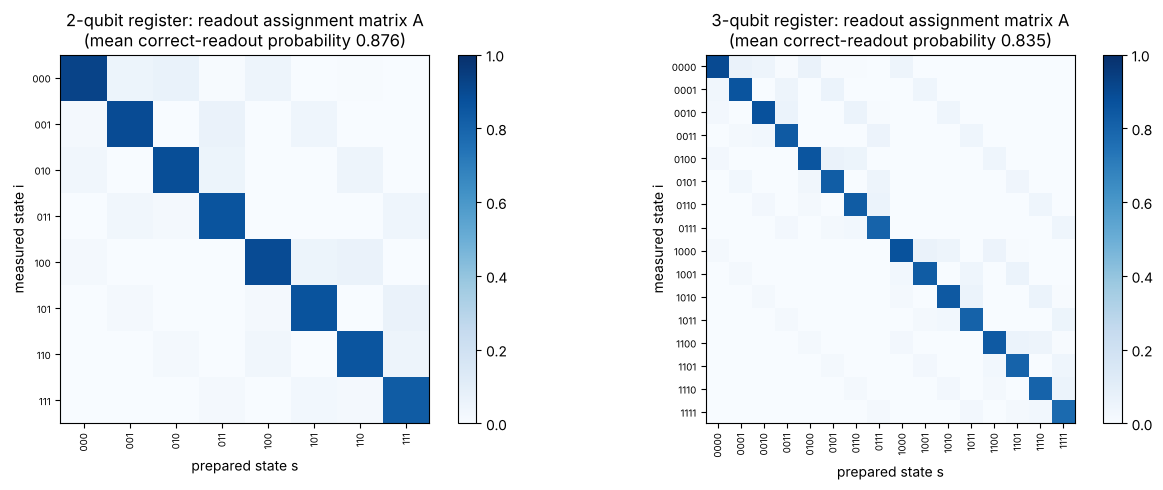

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
A_mats = {}
for ax, n in zip(axes, C.REGISTER_SIZES):
    dev = NoisyDevice(n, "gci")
    A = assignment_matrix(dev)
    A_mats[n] = A
    im = ax.imshow(A, cmap="Blues", vmin=0, vmax=1)
    labels = [format(i, f"0{n+1}b") for i in range(2 ** (n + 1))]
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel("prepared state s"); ax.set_ylabel("measured state i")
    ax.set_title(f"{n}-qubit register: readout assignment matrix A\n"
                 f"(mean correct-readout probability {np.mean(np.diag(A)):.3f})")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); save_fig(fig, "stage07_assignment_matrices.png"); plt.show()

lambda = 1:  depth =   32,  CZ gates =   8
lambda = 3:  depth =  134,  CZ gates =  24
lambda = 5:  depth =  236,  CZ gates =  40


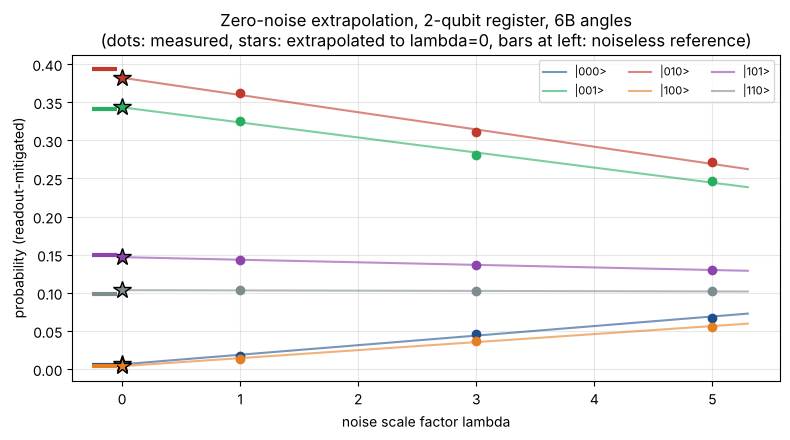

F_H at lambda=1: 0.9827   after ZNE: 0.9991


In [4]:
n = 2
dev = NoisyDevice(n, "gci")
x6b = np.array(s6[f"{n}_qubit"]["calibrated_parameters"]["auto_6B"])
bound = dev.bound_circuit(x6b)
for lam in C.ZNE_SCALE_FACTORS:
    f = fold_circuit(bound, lam)
    print(f"lambda = {lam}:  depth = {f.depth():4d},  CZ gates = {f.count_ops().get('cz', 0):3d}")

ref = dev.ideal_probs(np.array(s6[f"{n}_qubit"]["calibrated_parameters"]["uncalibrated"]))
probs = [apply_readout_mitigation(dev.run_circuit(fold_circuit(bound, lam), 50000, seed=7), A_mats[n])
         for lam in C.ZNE_SCALE_FACTORS]
p0 = zne_extrapolate(C.ZNE_SCALE_FACTORS, probs)

fig, ax = plt.subplots(figsize=(8, 4.5))
lams = np.array(C.ZNE_SCALE_FACTORS)
grid = np.linspace(0, 5.3, 50)
for i, c in zip([0, 1, 2, 4, 5, 6], [BLUE, GREEN, RED, ORANGE, PURPLE, GREY]):
    y = [p[i] for p in probs]
    a, b = np.polyfit(lams, y, 1)
    ax.plot(lams, y, "o", color=c)
    ax.plot(grid, a * grid + b, "-", color=c, alpha=0.6, label=f"|{i:03b}>")
    ax.plot(0, p0[i], "*", color=c, ms=13, mec="k")
    ax.plot(-0.15, ref[i], "_", color=c, ms=18, mew=3)
ax.set_xlabel("noise scale factor lambda"); ax.set_ylabel("probability (readout-mitigated)")
ax.set_title("Zero-noise extrapolation, 2-qubit register, 6B angles\n"
             "(dots: measured, stars: extrapolated to lambda=0, bars at left: noiseless reference)")
ax.legend(fontsize=8, ncol=3); ax.grid(alpha=0.3); plt.tight_layout()
save_fig(fig, "stage07_zne_extrapolation.png"); plt.show()
print(f"F_H at lambda=1: {hellinger_fidelity(probs[0], ref):.4f}   after ZNE: {hellinger_fidelity(p0, ref):.4f}")

In [5]:
execution = {}
for n in C.REGISTER_SIZES:
    execution[n] = execute_variants(n, s6[f"{n}_qubit"]["calibrated_parameters"], verbose=True)
    print()

  [2q] ideal_noiseless      F_H vs ideal = 1.0000 +/- 0.0000
  [2q] noisy_uncalibrated   F_H vs ideal = 0.8794 +/- 0.0026
  [2q] uncalibrated_REM     F_H vs ideal = 0.9218 +/- 0.0027
  [2q] 6A_grid_REM          F_H vs ideal = 0.9391 +/- 0.0022
  [2q] 6B_auto_REM          F_H vs ideal = 0.9819 +/- 0.0016
  [2q] 6B_auto_REM_ZNE      F_H vs ideal = 0.9983 +/- 0.0007



  [3q] ideal_noiseless      F_H vs ideal = 1.0000 +/- 0.0000
  [3q] noisy_uncalibrated   F_H vs ideal = 0.9189 +/- 0.0018
  [3q] uncalibrated_REM     F_H vs ideal = 0.9087 +/- 0.0025
  [3q] 6A_grid_REM          F_H vs ideal = 0.9564 +/- 0.0015
  [3q] 6B_auto_REM          F_H vs ideal = 0.9946 +/- 0.0007
  [3q] 6B_auto_REM_ZNE      F_H vs ideal = 0.9958 +/- 0.0008



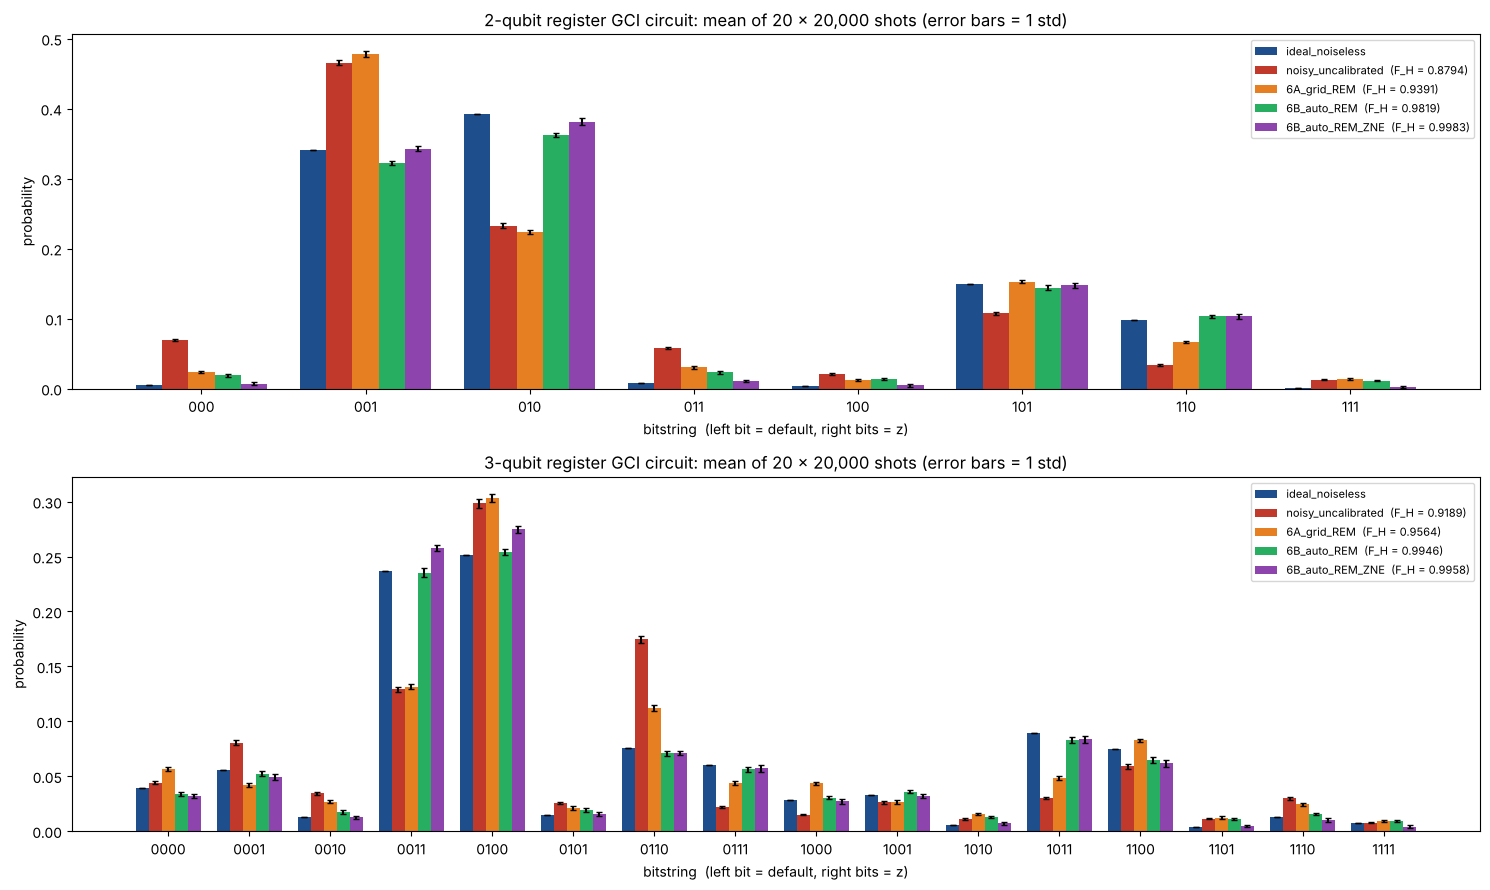

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))
show = ["ideal_noiseless", "noisy_uncalibrated", "6A_grid_REM", "6B_auto_REM", "6B_auto_REM_ZNE"]
for ax, n in zip(axes, C.REGISTER_SIZES):
    V = execution[n]["variants"]
    k = np.arange(2 ** (n + 1)); w = 0.8 / len(show)
    for i, key in enumerate(show):
        m, s = np.array(V[key]["mean_probs"]), np.array(V[key]["std_probs"])
        lab = key if key == "ideal_noiseless" else f"{key}  (F_H = {V[key]['fidelity_vs_ideal_mean']:.4f})"
        ax.bar(k + (i - len(show) / 2 + 0.5) * w, m, w, yerr=s, capsize=2, color=COLORS[key], label=lab)
    ax.set_xticks(k); ax.set_xticklabels([format(i, f"0{n+1}b") for i in k])
    ax.set_ylabel("probability"); ax.set_xlabel("bitstring  (left bit = default, right bits = z)")
    ax.set_title(f"{n}-qubit register GCI circuit: mean of {C.N_REPEATS} x {C.SHOTS_EXECUTION:,} shots (error bars = 1 std)")
    ax.legend(fontsize=8)
plt.tight_layout(); save_fig(fig, "stage07_execution_distributions.png"); plt.show()

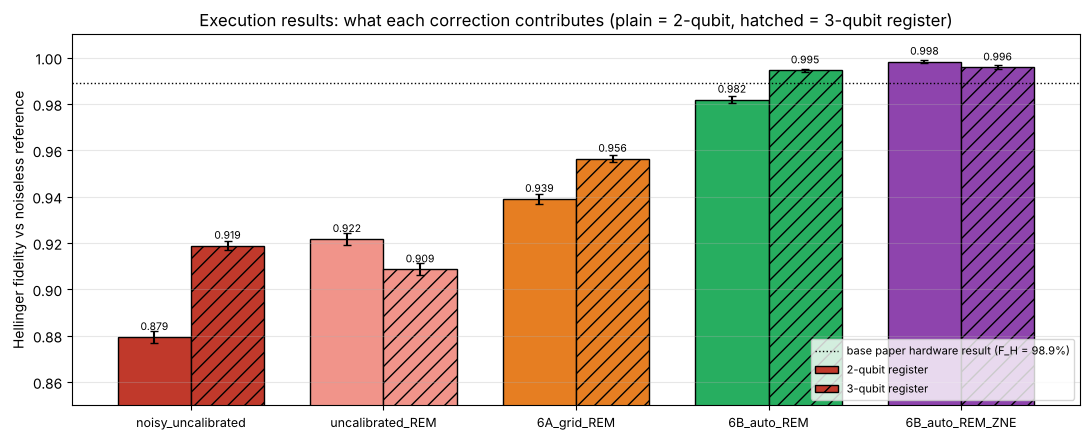

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.5))
keys = [k for k in VARIANT_DESCRIPTIONS if k != "ideal_noiseless"]
x = np.arange(len(keys)); w = 0.38
for j, n in enumerate(C.REGISTER_SIZES):
    V = execution[n]["variants"]
    m = [V[k]["fidelity_vs_ideal_mean"] for k in keys]
    s = [V[k]["fidelity_vs_ideal_std"] for k in keys]
    bars = ax.bar(x + (j - 0.5) * w, m, w, yerr=s, capsize=3, color=[COLORS[k] for k in keys],
                  edgecolor="k", hatch="" if n == 2 else "//", label=f"{n}-qubit register")
    for xi, v in zip(x + (j - 0.5) * w, m):
        ax.text(xi, v + 0.003, f"{v:.3f}", ha="center", fontsize=7.5)
ax.axhline(0.989, color="k", ls=":", lw=1, label="base paper hardware result (F_H = 98.9%)")
ax.set_xticks(x); ax.set_xticklabels(keys, fontsize=9)
ax.set_ylim(0.85, 1.01); ax.set_ylabel("Hellinger fidelity vs noiseless reference")
ax.set_title("Execution results: what each correction contributes (plain = 2-qubit, hatched = 3-qubit register)")
ax.legend(fontsize=8, loc="lower right"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); save_fig(fig, "stage07_fidelity_by_variant.png"); plt.show()

In [8]:
out = {"config": config_snapshot()}
for n in C.REGISTER_SIZES:
    out[f"{n}_qubit"] = execution[n]
path = save_json(out, "stage07_execution.json")
print(f"Saved -> {path}")
print("\nSummary (Hellinger fidelity vs noiseless reference, mean +/- std over repetitions):")
for n in C.REGISTER_SIZES:
    for k, v in execution[n]["variants"].items():
        print(f"  {n}q  {k:20s} {v['fidelity_vs_ideal_mean']:.4f} +/- {v['fidelity_vs_ideal_std']:.4f}")

Saved -> /home/claude/repo/results/stage07_execution.json

Summary (Hellinger fidelity vs noiseless reference, mean +/- std over repetitions):
  2q  ideal_noiseless      1.0000 +/- 0.0000
  2q  noisy_uncalibrated   0.8794 +/- 0.0026
  2q  uncalibrated_REM     0.9218 +/- 0.0027
  2q  6A_grid_REM          0.9391 +/- 0.0022
  2q  6B_auto_REM          0.9819 +/- 0.0016
  2q  6B_auto_REM_ZNE      0.9983 +/- 0.0007
  3q  ideal_noiseless      1.0000 +/- 0.0000
  3q  noisy_uncalibrated   0.9189 +/- 0.0018
  3q  uncalibrated_REM     0.9087 +/- 0.0025
  3q  6A_grid_REM          0.9564 +/- 0.0015
  3q  6B_auto_REM          0.9946 +/- 0.0007
  3q  6B_auto_REM_ZNE      0.9958 +/- 0.0008
